# Подключение необходимых библиотек

In [109]:
import numpy as np
import cupy as cp # Скачал с помощью команды !pip install cupy-cuda12x
import time

# Основная работа

In [110]:
def test_vector_sum(size):
    print(f"Размерность вектора: {size}")

    vec = np.random.rand(size).astype(np.float32)

    # Код выполнения на CPU
    _ = np.sum(vec)

    start = time.perf_counter()
    sum_cpu = np.sum(vec)
    cpu_time = time.perf_counter() - start

    # Код выполнения на GPU
    vec_gpu = cp.asarray(vec)
    _ = cp.sum(vec_gpu)
    cp.cuda.Stream.null.synchronize()

    start = time.perf_counter()
    sum_gpu = cp.sum(vec_gpu)
    cp.cuda.Stream.null.synchronize()
    gpu_time = time.perf_counter() - start

    sum_gpu_cpu = cp.asnumpy(sum_gpu)

    print(f"Сумма на CPU: {sum_cpu:.7f}")
    print(f"Время на CPU: {cpu_time:.7f} сек")
    print(f"Сумма на GPU: {sum_gpu_cpu:.7f}")
    print(f"Время на GPU: {gpu_time:.7f} сек\n")

    return cpu_time, gpu_time

# Запуск кода

In [111]:
sizes = [1000, 50000, 100000, 500000, 800000, 1000000]

cpu_times = []
gpu_times = []

for size in sizes:
    cpu_t, gpu_t = test_vector_sum(size)
    cpu_times.append(cpu_t)
    gpu_times.append(gpu_t)

Размерность вектора: 1000
Сумма на CPU: 490.9555969
Время на CPU: 0.0000133 сек
Сумма на GPU: 490.9555664
Время на GPU: 0.0001533 сек

Размерность вектора: 50000
Сумма на CPU: 25072.9199219
Время на CPU: 0.0000177 сек
Сумма на GPU: 25072.9199219
Время на GPU: 0.0000371 сек

Размерность вектора: 100000
Сумма на CPU: 50098.3437500
Время на CPU: 0.0000382 сек
Сумма на GPU: 50098.3476562
Время на GPU: 0.0000359 сек

Размерность вектора: 500000
Сумма на CPU: 250139.6250000
Время на CPU: 0.0001304 сек
Сумма на GPU: 250139.6562500
Время на GPU: 0.0000370 сек

Размерность вектора: 800000
Сумма на CPU: 400157.5000000
Время на CPU: 0.0002188 сек
Сумма на GPU: 400157.4375000
Время на GPU: 0.0000427 сек

Размерность вектора: 1000000
Сумма на CPU: 500403.2500000
Время на CPU: 0.0002638 сек
Сумма на GPU: 500403.3437500
Время на GPU: 0.0000391 сек



# Для README на github

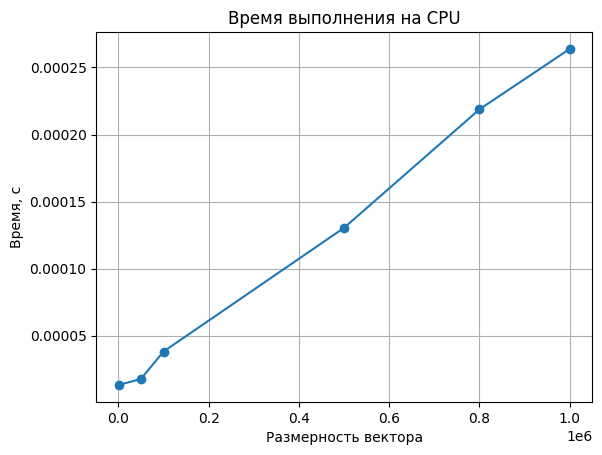

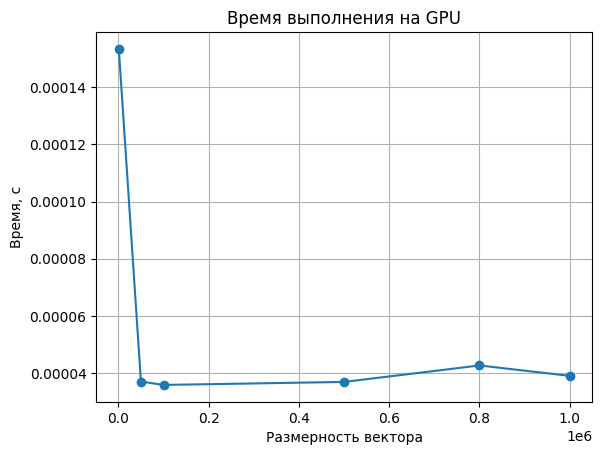

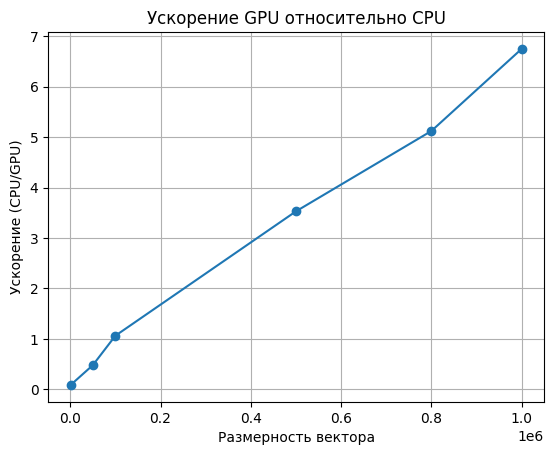

In [112]:
import matplotlib.pyplot as plt

# График 1 - время выполнения на CPU
plt.figure()
plt.plot(sizes, cpu_times, marker='o', linestyle='-')
plt.xlabel('Размерность вектора')
plt.ylabel('Время, с')
plt.title('Время выполнения на CPU')
plt.grid(True)
plt.show()

# График 2 - время выполнения на GPU
plt.figure()
plt.plot(sizes, gpu_times, marker='o', linestyle='-')
plt.xlabel('Размерность вектора')
plt.ylabel('Время, с')
plt.title('Время выполнения на GPU')
plt.grid(True)
plt.show()

# График 3 - ускорение (CPU/GPU)
speedups = [cpu / gpu for cpu, gpu in zip(cpu_times, gpu_times)]
plt.figure()
plt.plot(sizes, speedups, marker='o', linestyle='-')
plt.xlabel('Размерность вектора')
plt.ylabel('Ускорение (CPU/GPU)')
plt.title('Ускорение GPU относительно CPU')
plt.grid(True)
plt.show()